In [1]:
%cd ../

/home/dmoreno/pipeline_v4_final/pipeline/training/lc_classifiers/models/paper_versions/ztf_ff


In [2]:
%ls

data/             images/      models/     __pycache__/  results_prod/
download_data.sh  images_old/  notebooks/  README.md     schema.py


In [3]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import os
#os.environ["PATH"] = "/home/users/dmoreno2016/.TinyTeX/bin/x86_64-linux:" + os.environ["PATH"]

#plt.rcParams.update({
#    "text.usetex": True,
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "font.serif": ["Palatino"],
#})

import warnings
warnings.filterwarnings('ignore')

In [4]:
#"SESN": ("SNIbc", "SNIIb")

In [5]:
objects = pd.read_parquet('data/preprocessed/objects.parquet')
objects = objects[objects.alerceclass != 'ZZ']
objects

,ra,dec,submitter,alerceclass
oid,,,,
ZTF21aanrvaz,227.999259,-21.317113,amunoz,AGN
ZTF17aaazlzl,120.870621,33.462329,amunoz,AGN
ZTF21acqoruu,297.425121,3.303783,amunoz,AGN
ZTF22aaafnol,165.188738,62.921204,amunoz,AGN
ZTF22aaaokdq,219.567335,-6.972391,amunoz,AGN
...,...,...,...,...
ZTF23aabwxqa,83.719860,-5.014108,amunoz,YSO
ZTF23aamaycf,292.536145,18.400967,amunoz,YSO
ZTF23aaoscaj,335.449414,58.712143,amunoz,YSO


In [6]:
mapping = {
    "SNIa": "SNIa",
    # --- Solución al conflicto SESN ---
    "SNIbc": "SNIbc",   # Mantiene SNIbc real como SNIbc
    "SNIIb": "Others",  # Manda SNIIb real a Others
    "SESN": "SNIbc",    # Mapea la predicción SESN a la clase SNIbc
    # ----------------------------------
    "SNII": "SNII",
    "SNIIn": "SNII",
    "SLSN": "SLSN",
    "TDE": "Others",  # Se ignora
    "Microlensing": "Others",  # Se ignora
    "QSO": "QSO",
    "AGN": "AGN",
    "Blazar": "Blazar",
    "YSO": "YSO",
    "CV/Nova": "CV/Nova",
    "LPV": "LPV",
    "EA": "E",
    "EB/EW": "E",
    "Periodic-Other": "Periodic-Other",
    "RSCVn": "Periodic-Other",
    "CEP": "CEP",
    "RRLab": "RRL",
    "RRLc": "RRL",
    "DSCT": "DSCT"
}

order_classes_sanchez_tax = [
    "SNIa", "SNIbc", "SNII", "SLSN",
    "QSO", "AGN", "Blazar",
    "YSO", "CV/Nova", "LPV", "E",
    "DSCT", "RRL", "CEP", "Periodic-Other", "Others"
    ]

class_hierarchy_sanchez_tax = {
    "Transient": ["SNIa", "SNIbc", "SNII", "SLSN"],
    "Periodic": [
        "LPV",
        "E",
        "Periodic-Other",
        "CEP",
        "RRL",
        "DSCT",
    ],
    "Stochastic": [
        "QSO",
        "AGN",
        "Blazar",
        "YSO",
        "CV/Nova",
    ],
}

# Lista de días evaluados
list_time_eval = ['8', '16', '32', '64', '128', '256', '512', '1024', 'None']

path_save_imgs = 'images'

os.makedirs(f'{path_save_imgs}', exist_ok=True)

In [7]:
mlflow.set_tracking_uri("file:./models/ATAT/results/ml-runs")

data_name =  'ztf_ff_20folds'
experiment_name = f"classification/{data_name}/testing"

experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment:
    experiment_id = experiment.experiment_id
    print(f"Experiment ID for '{experiment_name}': {experiment_id}")
else:
    print(f"Experiment '{experiment_name}' not found.")

runs = mlflow.search_runs(experiment_ids=[experiment_id])
runs = runs[
    (runs.status == 'FINISHED') & 
    (runs['metrics.mix/f1s_test/None_days'].notna())
    ]

# Identificadores de cada fold
fold_run = {v: k for k, v in zip(runs['run_id'], runs['params.general/fold'])}

display(runs.head())
print(runs.shape)
print(fold_run)

Experiment ID for 'classification/ztf_ff_20folds/testing': 962229171665423791


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.loss_test/512_days/mix_entropy,metrics.loss_test/256_days/mix,metrics.mix/rcl_test/1024_days,metrics.loss_test/1024_days/tab,...,params.lc/num_bands,params.lc/embedding_size,params.general/experiment_type,params.general/use_only_det,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.source.git.commit,tags.mlflow.source.name,tags.mlflow.parentRunId,tags.mlflow.runName
0,dcbfbec41dbf4a008a0b2f4f3809614d,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-07 11:21:00.885000+00:00,2026-02-07 17:31:39.408000+00:00,-0.230731,0.384711,0.717253,0.339477,...,2,96,lc_md_feat_mta,False,dmoreno,LOCAL,6ed63fd1e72375e122564f67cd157af5f7605281,training.py,93a3c947d5964aa69440af94e4facc44,Fold_19_2026-02-07_02-46-14
1,d516bf190eb044c48e71aa087daec9ad,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-07 02:46:14.298000+00:00,2026-02-07 11:21:00.881000+00:00,-0.221716,0.379511,0.716108,0.330833,...,2,96,lc_md_feat_mta,False,dmoreno,LOCAL,6ed63fd1e72375e122564f67cd157af5f7605281,training.py,93a3c947d5964aa69440af94e4facc44,Fold_18_2026-02-07_02-46-14
3,0b3d05b786154f669547663574bb2b94,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 13:43:28.361000+00:00,2026-02-06 22:10:40.014000+00:00,-0.214883,0.383737,0.720197,0.331690,...,2,96,lc_md_feat_mta,False,dmoreno,LOCAL,6ed63fd1e72375e122564f67cd157af5f7605281,training.py,fa103dedc1b6410791914ad67bb7a893,Fold_14_2026-02-05_18-44-25
4,bb2d6a5e93af4dd3a27f5439d1c297cb,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 08:07:49.485000+00:00,2026-02-06 14:37:41.611000+00:00,-0.246937,0.379439,0.709830,0.345429,...,2,96,lc_md_feat_mta,False,dmoreno,LOCAL,6ed63fd1e72375e122564f67cd157af5f7605281,training.py,01eacf7990894d68b04250b6e764ec06,Fold_17_2026-02-05_18-46-07
5,2da58ec77ef7470e8987dd991ab265a4,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 03:17:33.812000+00:00,2026-02-06 13:43:28.357000+00:00,-0.203942,0.389232,0.724333,0.324393,...,2,96,lc_md_feat_mta,False,dmoreno,LOCAL,6ed63fd1e72375e122564f67cd157af5f7605281,training.py,fa103dedc1b6410791914ad67bb7a893,Fold_13_2026-02-05_18-44-25


(20, 214)
{'19': 'dcbfbec41dbf4a008a0b2f4f3809614d', '18': 'd516bf190eb044c48e71aa087daec9ad', '14': '0b3d05b786154f669547663574bb2b94', '17': 'bb2d6a5e93af4dd3a27f5439d1c297cb', '13': '2da58ec77ef7470e8987dd991ab265a4', '16': 'e687ac031e42466c83b19d4ed7cec1c5', '15': 'b2d113b4bef94e94ab123c0e34deb6a9', '12': '7cee5e534275413a9d2e45accda17bfc', '11': '40b50aeb8bae4db3af2ae30c9737de05', '8': 'e4c429d353714261838546b48aefc7fa', '10': 'd9af533c04274318b47b94e1874b68b3', '7': '51a58a2ff9814ac7815d72745c8c756e', '9': 'b410a7b202c14ca49612c8da1e8883ca', '6': '479b33e2708d4c75aab5db562691ae93', '5': 'd3a7920e140d4345b11190d1c800dad8', '2': '8eda2f2d74c140aa8ea3edd93ed6d0d6', '4': 'f4278fd6d3d04015b065722e135ca8af', '1': 'e70d10ce7f024bd582d714e0db72d3ee', '3': 'd5f7f1ca1ef848d8ba1e5dfc406dacd4', '0': '83a5f4135292475ca54b0c15122f3db6'}


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Inicializar estructuras para almacenar resultados
atat_y_pred_fold = {}
hbrf_y_pred_fold = {}
combined_y_pred_fold = {}
y_test_fold = {}

# Iterar sobre los valores de time_eval (días)
for time_eval in list_time_eval:
    atat_y_pred_fold[f'{time_eval}_days'] = []
    hbrf_y_pred_fold[f'{time_eval}_days'] = []
    combined_y_pred_fold[f'{time_eval}_days'] = []
    y_test_fold[f'{time_eval}_days'] = []  # Guardar valores reales (y_true)

    for fold, run_id in fold_run.items():
        # Cargar predicciones de ATAT
        path_clf_report = f'./models/ATAT/results/ml-runs/{experiment_id}/{run_id}/artifacts'
        atat_df_predictions = pd.read_parquet(f'{path_clf_report}/ndays_results/LCs/predictions_test_{time_eval}.parquet').set_index('id')
        atat_df_predictions['y_true'] = objects.reindex(atat_df_predictions.index).alerceclass
        
        y_test = atat_df_predictions['y_true'].values
        atat_y_pred = atat_df_predictions['y_pred'].values

        y_test = [mapping[label] for label in y_test]
        atat_y_pred = [mapping[label] for label in atat_y_pred]

        # Cargar predicciones de HBRF
        root = 'models/HBRF/results/250408_ndetge8_20folds/HBRF_20251229-182152'
        hbrf_df_predictions = pd.read_parquet(f'{root}/fold_{fold}/predictions_test.parquet')
        hbrf_df_predictions = hbrf_df_predictions[hbrf_df_predictions['shorten'] == time_eval]
        hbrf_df_predictions.index = hbrf_df_predictions.index.astype(str).str.split('_').str[1]
        hbrf_df_predictions = hbrf_df_predictions.reindex(atat_df_predictions.index)
        hbrf_y_pred = hbrf_df_predictions['y_pred'].values

        hbrf_y_pred = [mapping[label] for label in hbrf_y_pred]

        # Promediar predicciones de ATAT y HBRF
        #combined_y_pred_prob_fold = (atat_df_predictions[order_classes] + hbrf_df_predictions[order_classes]) / 2
        
        # Guardar valores en estructuras
        atat_y_pred_fold[f'{time_eval}_days'].append(atat_y_pred)
        hbrf_y_pred_fold[f'{time_eval}_days'].append(hbrf_y_pred)
        #combined_y_pred_fold[f'{time_eval}_days'].append(combined_y_pred_prob_fold.idxmax(axis=1))
        y_test_fold[f'{time_eval}_days'].append(y_test)


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

metrics_by_time = {time_eval: {"ATAT": [], "HBRF": []} for time_eval in list_time_eval}
confusion_matrices = {} 

for time_eval in list_time_eval:
    for fold in range(len(fold_run)):  # Iterar sobre los folds
        y_test = y_test_fold[f"{time_eval}_days"][fold]
        y_pred_atat = atat_y_pred_fold[f"{time_eval}_days"][fold]
        y_pred_hbrf = hbrf_y_pred_fold[f"{time_eval}_days"][fold]

        # Calcular reporte de métricas inter
        report_atat_inter = classification_report(y_test, y_pred_atat, output_dict=True)
        report_hbrf_inter = classification_report(y_test, y_pred_hbrf, output_dict=True)

        # Guardar métricas
        metrics_by_time[time_eval]["ATAT"].append(report_atat_inter)
        metrics_by_time[time_eval]["HBRF"].append(report_hbrf_inter)

        # Guardar matrices de confusión solo cuando time_eval es None
        if time_eval == 'None':
            if time_eval not in confusion_matrices:
                confusion_matrices[time_eval] = {"ATAT": [], "HBRF": []}
            
            cm_atat = confusion_matrix(y_test, y_pred_atat, labels=order_classes_sanchez_tax)
            cm_hbrf = confusion_matrix(y_test, y_pred_hbrf, labels=order_classes_sanchez_tax)

            confusion_matrices[time_eval]["ATAT"].append(cm_atat)
            confusion_matrices[time_eval]["HBRF"].append(cm_hbrf)

In [10]:
import pandas as pd
import numpy as np

# Diccionario dinámico para almacenar los datos de cada categoría
data_inter = {category: [] for category in order_classes_sanchez_tax}
data_inter_macro = []

for time_eval in list_time_eval:
    for category in order_classes_sanchez_tax:
        row = [time_eval]
        for model in ["ATAT", "HBRF"]:
            recalls = [metrics_by_time[time_eval][model][fold][category]["recall"] * 100 
                       for fold in range(len(fold_run))]
            precision = [metrics_by_time[time_eval][model][fold][category]["precision"] * 100 
                         for fold in range(len(fold_run))]
            f1_score = [metrics_by_time[time_eval][model][fold][category]["f1-score"] * 100 
                        for fold in range(len(fold_run))]

            row.extend([
                f"{np.mean(precision):.2f} ± {np.std(precision):.2f}",
                f"{np.mean(recalls):.2f} ± {np.std(recalls):.2f}",
                f"{np.mean(f1_score):.2f} ± {np.std(f1_score):.2f}"
            ])

        # Guardar la fila en el diccionario correspondiente a la categoría
        data_inter[category].append(row)

    # Calcular y guardar macro promedio por cada time_eval
    row_macro = [time_eval]
    for model in ["ATAT", "HBRF"]:
        macro_precision = [metrics_by_time[time_eval][model][fold]["macro avg"]["precision"] * 100 
                           for fold in range(len(fold_run))]
        macro_recall = [metrics_by_time[time_eval][model][fold]["macro avg"]["recall"] * 100 
                        for fold in range(len(fold_run))]
        macro_f1 = [metrics_by_time[time_eval][model][fold]["macro avg"]["f1-score"] * 100 
                    for fold in range(len(fold_run))]

        row_macro.extend([
            f"{np.mean(macro_precision)} ± {np.std(macro_precision)}",
            f"{np.mean(macro_recall)} ± {np.std(macro_recall)}",
            f"{np.mean(macro_f1)} ± {np.std(macro_f1)}"
        ])
    
    data_inter_macro.append(row_macro)

# Crear DataFrames para cada categoría dinámicamente
columns = ["Time (days)", 
           "ATAT Precision", "ATAT Recall", "ATAT F1-score",
           "HBRF Precision", "HBRF Recall", "HBRF F1-score"]

df_inter = {category: pd.DataFrame(data, columns=columns).set_index("Time (days)") 
            for category, data in data_inter.items()}

# Crear DataFrame para Macro Promedio
df_inter_macro = pd.DataFrame(data_inter_macro, columns=columns).set_index("Time (days)")

# -------------------------------
# **MOSTRAR RESULTADOS**
# -------------------------------
display(df_inter_macro.head())
print(f'Number of classes: {len(df_inter)}')

,ATAT Precision,ATAT Recall,ATAT F1-score,HBRF Precision,HBRF Recall,HBRF F1-score
Time (days),,,,,,
8,68.23193542650095 ± 1.0767673032515814,66.40911847931386 ± 0.7705535734722121,65.63782291670977 ± 0.8917218481546472,61.51763434163814 ± 0.27864938071306333,65.248925562615 ± 0.3369983611607725,61.96382984023917 ± 0.3021977497668411
16,72.9634844485689 ± 1.2131793773982202,70.40033949553566 ± 0.7438678747168355,70.1583545229947 ± 0.9069162250408254,66.75719591968733 ± 0.35663731155976336,70.3634853797021 ± 0.37351347857071504,67.81269267946354 ± 0.37051999159943133
32,76.8980441367792 ± 1.0326741817750074,74.17931319271517 ± 0.7114922364371001,74.24424534657166 ± 0.654425989439851,72.91860331056935 ± 0.23557351199940998,75.61253573396382 ± 0.26824361015281095,73.83347156142746 ± 0.21656177434159526
64,79.39428415773136 ± 0.8795781768767598,76.602445967854 ± 0.6481327372831408,76.8880250669243 ± 0.6530018223226759,75.7871055930568 ± 0.3029332127936345,77.80528732055443 ± 0.3599494694054977,76.46412457657291 ± 0.2913668767857785
128,80.87576689450951 ± 0.875200986857347,77.70791718323005 ± 0.5126688901327211,78.19887779398367 ± 0.5206068252212843,76.98461396337939 ± 0.27815062762362525,78.4787702053994 ± 0.2318839853893414,77.44197206718533 ± 0.20290318316018965


Number of classes: 16


In [11]:
def get_mean_std(list_values):
    means = []
    std_devs = []
    for values in list_values:
        mean, std_dev = values.split(" ± ")
        means.append(float(mean))
        std_devs.append(float(std_dev))
    return means, std_devs

In [12]:
atat_f1, atat_f1_err =  get_mean_std(df_inter_macro['ATAT F1-score'].values)
hbrf_f1, hbrf_f1_err =  get_mean_std(df_inter_macro['HBRF F1-score'].values)
days = [int(k) if k != 'None' else 2039 for k in df_inter_macro.index.values]

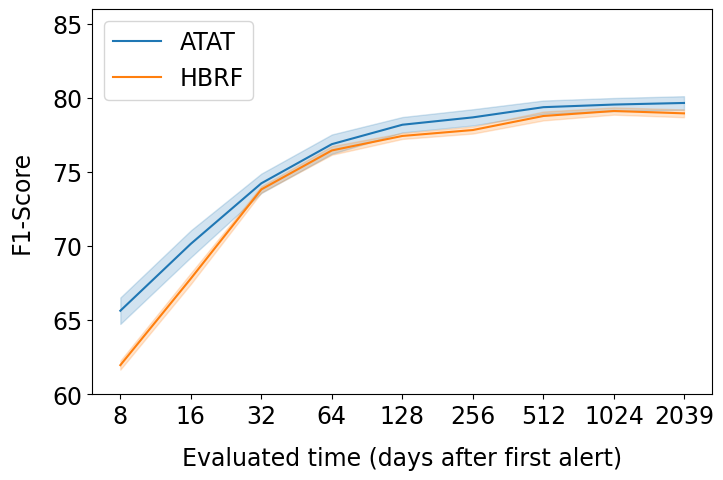

In [13]:
# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(8, 5))

# Graficar los datos con barras de error
ax.plot(days, atat_f1, linestyle='-', label='ATAT', color='tab:blue')
ax.plot(days, hbrf_f1, linestyle='-', label='HBRF', color='tab:orange')

ax.fill_between(days, np.array(atat_f1) - np.array(atat_f1_err), np.array(atat_f1) + np.array(atat_f1_err), color='tab:blue', alpha=0.2)
ax.fill_between(days, np.array(hbrf_f1) - np.array(hbrf_f1_err), np.array(hbrf_f1) + np.array(hbrf_f1_err), color='tab:orange', alpha=0.2)

# Resaltar el máximo F1-score de todos los modelos
max_f1 = max(max(atat_f1), max(hbrf_f1))
max_idx = None
max_day = None

# Determinar a qué modelo y día pertenece el máximo F1-score
for idx, (a, h) in enumerate(zip(atat_f1, hbrf_f1)):
    if max_f1 in [a, h]:  # Verificar a qué curva pertenece
        max_idx = idx
        max_day = days[idx]
        break

# Dibujar línea y anotación del máximo F1-score
#ax.axhline(y=max_f1, linestyle='dashed', color='gray', alpha=0.6)
#ax.text(max_day, max_f1 + 0.01, f"Max F1: {max_f1:.3f}", ha="center", fontsize=10, color="gray", fontweight="bold")

# Configurar el eje X con escala logarítmica en base 2
list_time_to_eval = sorted(days)  # Asegurar que los valores estén ordenados
ax.set_xscale('log', base=2)
ax.set_xticks(list_time_to_eval)

# Configurar etiquetas, título y límites
fs = 17
#ax.set_title('F1-Score by Evaluation Time', fontsize=fs + 2, fontweight='bold', pad=15)
ax.set_xlabel('Evaluated time (days after first alert)', fontsize=fs, labelpad=13)
ax.set_ylabel('F1-Score', fontsize=fs, labelpad=13)
ax.tick_params(axis='y', labelsize=fs)
ax.set_xticklabels(list_time_to_eval, fontsize=fs)
ax.set_ylim(60, 86)
ax.legend(fontsize=fs, loc='upper left')

# Mostrar la gráfica
plt.savefig(f"{path_save_imgs}/eval_time_bottom_lvl_new_to_sanchez_tax.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_confusion_matrix(matrices, order_classes, class_hierarchy=None, path_save=None, figsize=(13, 13), shrink=0.675):
    # Calculando la media y la desviación estándar
    median_matrix = np.median(matrices, axis=0)
    p5_matrix = np.abs(median_matrix - np.percentile(matrices, 5, axis=0))
    p95_matrix = np.abs(median_matrix - np.percentile(matrices, 95, axis=0)) 

    matrices_norm = np.array([m / m.sum(axis=1, keepdims=True) for m in matrices])
    matrices_norm = np.nan_to_num(matrices_norm)
    mean_matrices_norm = np.mean(matrices_norm, axis=0)
        
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=figsize) 
    im = ax.imshow(np.around(mean_matrices_norm, decimals=2), interpolation='nearest', cmap=cmap, aspect=.9, vmax=1)

    cbar = plt.colorbar(im, ax=ax, pad=0.02, aspect=40, shrink=shrink)
    cbar.ax.tick_params(labelsize=17)

    new_color = cmap(1.0) 

    # Añadiendo anotaciones
    for i in range(median_matrix.shape[0]):
        for j in range(median_matrix.shape[1]):
            mean_val = int(median_matrix[i, j])
            p5_val = int(p5_matrix[i, j])
            p95_val = int(p95_matrix[i, j])

            if mean_matrices_norm[i, j] >= 0.0005:
                text = f'{mean_val}'
                text_p95 = f'+{p95_val}' if p95_val != 0 else ''
                text_p5 = f'−{p5_val}' if p5_val != 0 else ''

                color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color

                ax.text(j - 0.13, i, text, ha="center", va="center", color=color, fontsize=15.5)
                ax.text(j + 0.018, i - 0.15, text_p95, ha="left", va="bottom", color=color, fontsize=11)
                ax.text(j + 0.018, i + 0.15, text_p5, ha="left", va="top", color=color, fontsize=11)
            else:
                text = f'{mean_val}'
                color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)

    # Ajustes ejes
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    if class_hierarchy is not None:
        for class_list in class_hierarchy.values():
            indices = [order_classes.index(cls) for cls in class_list if cls in order_classes]
            if indices:
                min_idx, max_idx = min(indices), max(indices)
                rect = patches.Rectangle(
                    (min_idx - 0.5, min_idx - 0.5),
                    max_idx - min_idx + 1,
                    max_idx - min_idx + 1,
                    linewidth=2, edgecolor="black", facecolor='none', clip_on=False
                )
                ax.add_patch(rect)

    ax.set_ylabel('True Label', fontsize=17)
    ax.set_xlabel('Predicted Label', fontsize=17)

    plt.setp(ax.get_xticklabels(), rotation=65, ha='center', va='top', rotation_mode="default")
    plt.tight_layout()

    # MODIFICACIÓN CLAVE: NO HACEMOS PLT.SHOW AQUÍ DENTRO
    # Si pasamos path_save, guardamos, pero no cerramos la figura.
    if path_save is not None:
        plt.savefig(f"{path_save}", format="pdf", bbox_inches="tight")
    
    return ax  # Retornamos el eje para poder editarlo fuera

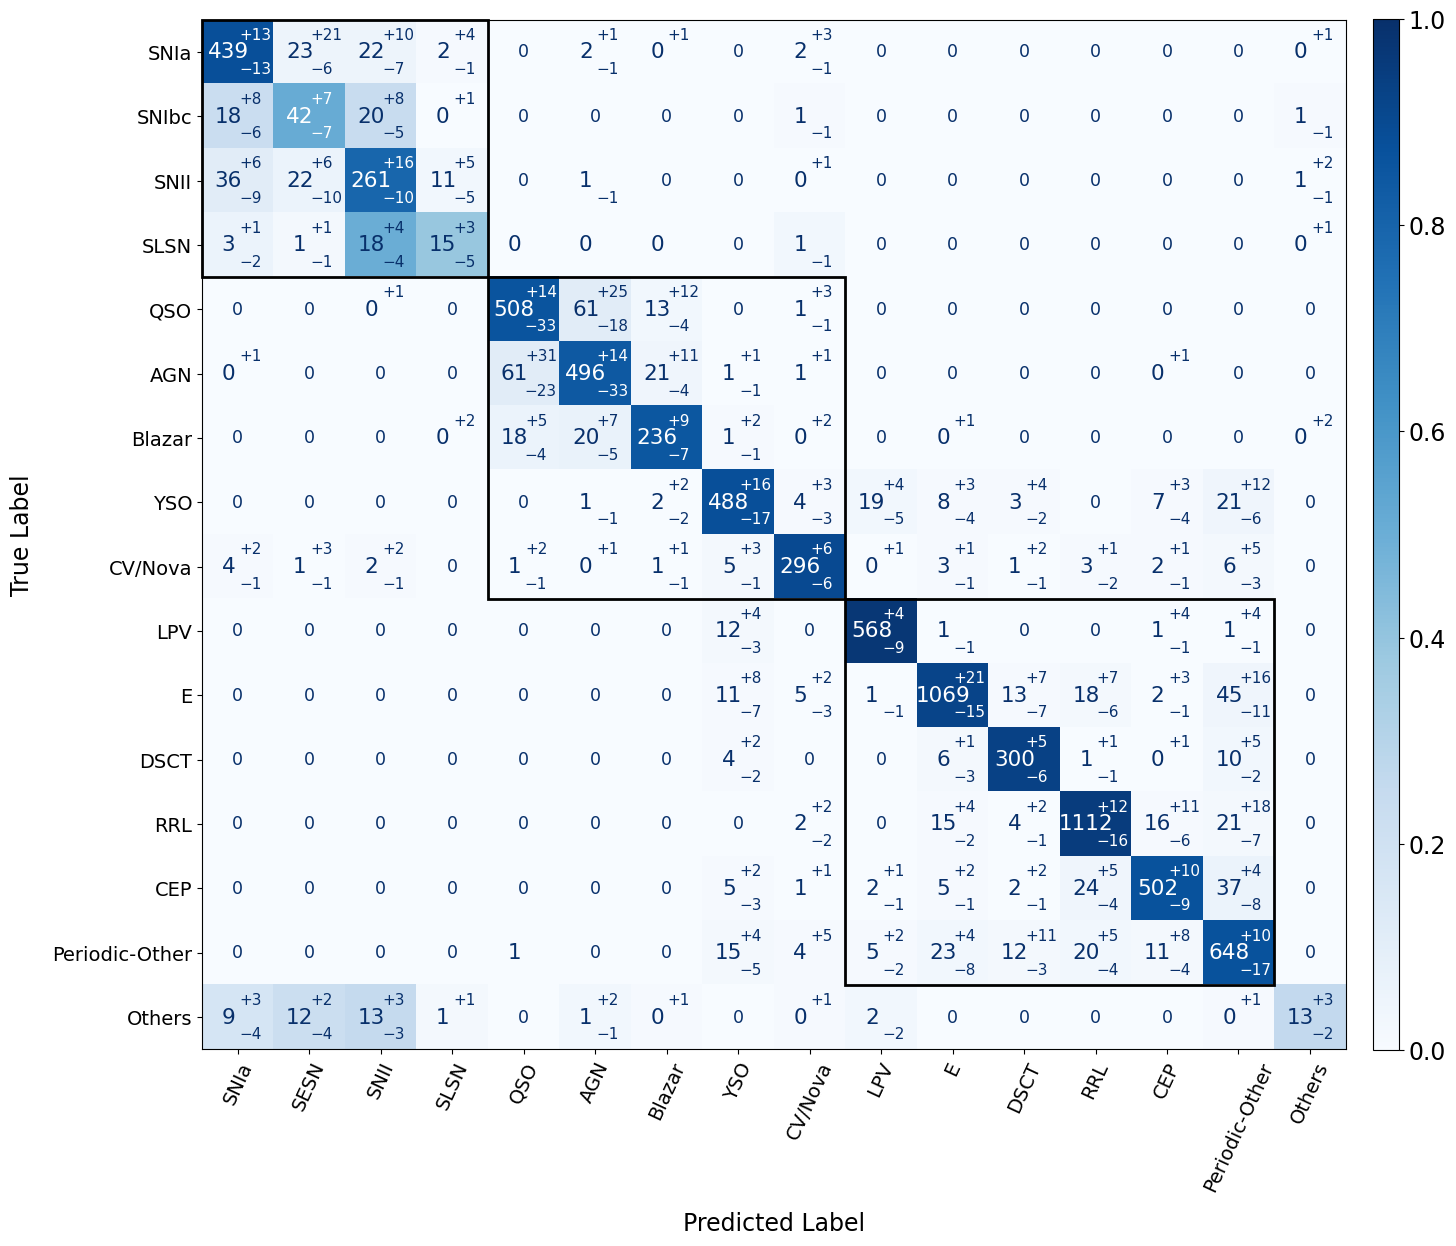

In [15]:
# Crear lista de etiquetas VISUALES para el eje X (Predicciones)
# Reemplazamos "SNIbc" por "SESN" solamente en la visualización
visual_pred_labels = [label if label != "SNIbc" else "SESN" for label in order_classes_sanchez_tax]

# --- Graficar ATAT ---
if 'ATAT' in confusion_matrices['None']:
    matrices = confusion_matrices['None']['ATAT']
    path_save = f'{path_save_imgs}/cm_atat_bottom_lvl_new_to_sanchez_tax.pdf'

    # 1. Llamamos a la función SIN path_save para que no guarde todavía
    ax = get_confusion_matrix(matrices, order_classes_sanchez_tax, class_hierarchy=class_hierarchy_sanchez_tax, path_save=None, figsize=(16,13), shrink=0.92)

    # 2. SOBREESCRIBIMOS EL EJE X para que diga SESN
    ax.set_xticklabels(visual_pred_labels)
    ax.set_xlabel('Predicted Label', fontsize=17) # Opcional

    # 3. Ahora sí guardamos y mostramos
    plt.savefig(path_save, format="pdf", bbox_inches="tight")
    plt.show()

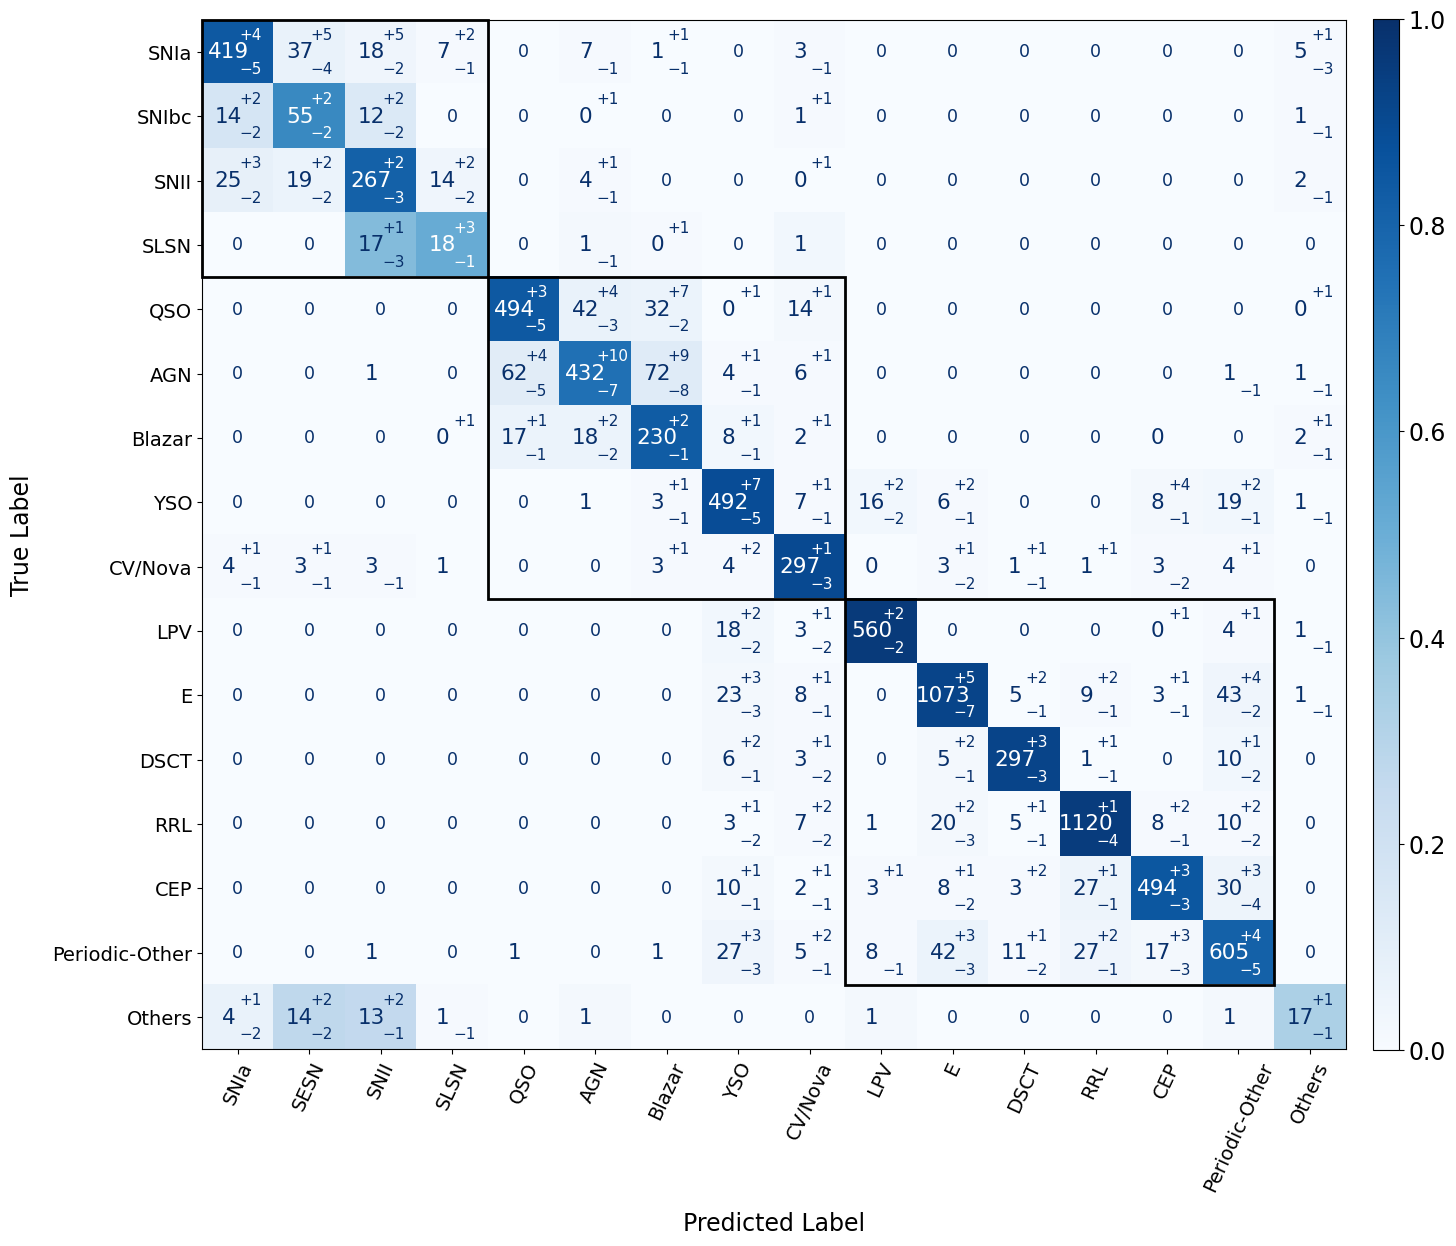

In [16]:
# --- Graficar HBRF ---
if 'HBRF' in confusion_matrices['None']:
    matrices = confusion_matrices['None']['HBRF']
    path_save = f'{path_save_imgs}/cm_hbrf_bottom_lvl_new_to_sanchez_tax.pdf'

    ax = get_confusion_matrix(matrices, order_classes_sanchez_tax, class_hierarchy=class_hierarchy_sanchez_tax, path_save=None, figsize=(16,13), shrink=0.92)

    # 2. SOBREESCRIBIMOS EL EJE X para que diga SESN
    ax.set_xticklabels(visual_pred_labels)
    ax.set_xlabel('Predicted Label', fontsize=17) # Opcional

    plt.savefig(path_save, format="pdf", bbox_inches="tight")
    plt.show()